In [79]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [80]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [81]:
X

array([[-1.37407053,  6.28268294],
       [-6.90572859, -8.52061602],
       [-3.36345929, -9.01648785],
       ...,
       [-1.39203448,  9.51066007],
       [-6.43129418, -6.74384468],
       [-6.68640025, -6.58358619]], shape=(1000, 2))

In [82]:
y

array([2, 0, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 1, 1, 2, 1, 0, 2, 1,
       0, 1, 1, 1, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 1, 0, 2, 1, 2, 1,
       0, 0, 2, 1, 2, 0, 1, 2, 2, 0, 0, 1, 1, 0, 2, 1, 1, 0, 1, 2, 2, 2,
       1, 0, 1, 1, 0, 1, 0, 2, 1, 2, 2, 1, 0, 0, 2, 2, 2, 0, 1, 2, 0, 2,
       2, 2, 1, 2, 2, 0, 1, 2, 1, 2, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1, 1, 2,
       1, 0, 0, 0, 1, 1, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       1, 1, 1, 2, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 2, 2, 0, 2, 1, 1, 2,
       0, 0, 1, 1, 1, 2, 1, 2, 2, 1, 0, 0, 1, 2, 0, 1, 0, 1, 2, 1, 2, 2,
       1, 2, 0, 2, 0, 1, 0, 2, 0, 1, 2, 1, 0, 2, 2, 1, 0, 0, 1, 0, 1, 0,
       0, 2, 0, 0, 0, 2, 2, 2, 2, 1, 0, 1, 0, 1, 2, 1, 0, 2, 0, 2, 2, 2,
       0, 0, 1, 2, 2, 1, 1, 2, 0, 0, 2, 1, 0, 2, 1, 2, 2, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 2, 0, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 1, 2, 2, 1, 1, 0, 1, 2, 2,
       1, 1, 0, 1, 0, 2, 1, 0, 1, 2, 1, 1, 2, 2, 1,

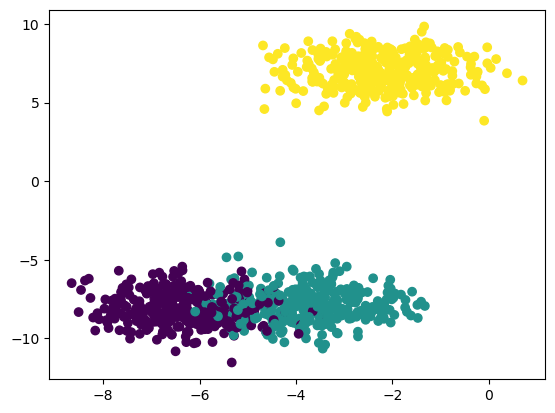

In [83]:
plt.scatter(X[:,0],X[:,1],c=y)

In [84]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [85]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [86]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
from sklearn.cluster import KMeans

In [88]:
## Elbow Method to select the K value
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [89]:
wcss

[1340.0000000000002,
 363.09591991472035,
 159.77079980041077,
 120.12221879577166,
 77.35342216928532,
 61.744025712900644,
 50.05506532457865,
 40.92735033291652,
 37.05284987709223,
 34.96038067344396]

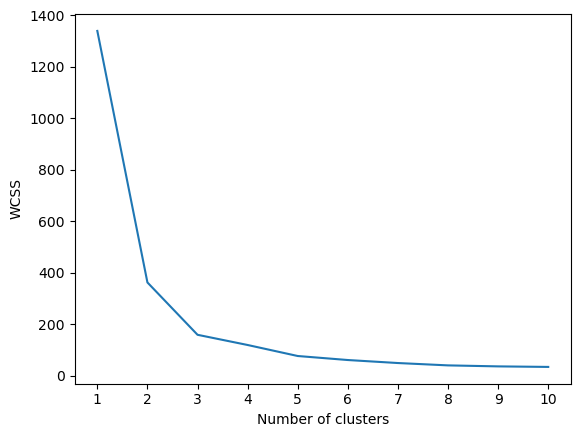

In [90]:
## Plot elbow cruve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [91]:
kmeans = KMeans(n_clusters=2,init="k-means++")

In [92]:
kmeans.fit_predict(X_train_scaled)

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,

In [93]:
y_pred = kmeans.predict(X_test_scaled)

In [94]:
y_pred

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,

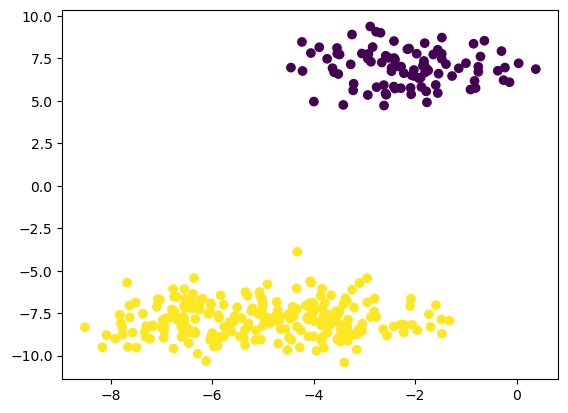

In [95]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [96]:
## Validating the k value
## Knee Locator 
## Silhoutee Scoring


In [97]:
from kneed import KneeLocator 

In [98]:
k1 = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [99]:
k1.elbow

np.int64(3)

In [100]:
## Silhotte score
from sklearn.metrics import silhouette_score

In [103]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [105]:
silhouette_coefficients

[0.6698049140993715,
 0.6231026725495873,
 0.5670760477313254,
 0.534653362653441,
 0.4594800771195566,
 0.4569130196262283,
 0.44658342107858984,
 0.4385739796714318,
 0.4156674746157684]

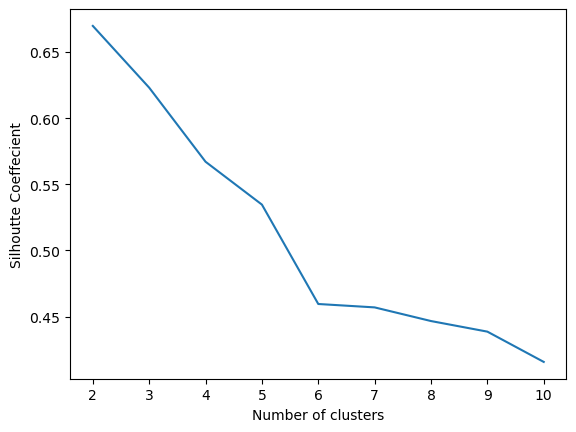

In [108]:
## Plot elbow cruve
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()